In [46]:
import pandas as pd

# 1. Load the datasets
df_area = pd.read_csv('final_imputed_crown_area.csv')
df_height = pd.read_csv('trees_full_with_imputed_crown_height.csv')

# 2. Define the exact columns you want to bring over from df_height
# (Make sure to include OBJECTID so we can match the rows!)
columns_to_keep = [
    'OBJECTID', 
    'tree_group', 
    'CROWN_HEIGHT_interpolated', 
    'height_imputed_flag', 
    'height_model_source'
]

# 3. Merge the datasets
# A 'left' merge keeps everything in df_area and only brings in matching data from df_height
df_combined = df_area.merge(df_height[columns_to_keep], on='OBJECTID', how='left')

# 4. Quick verification
print("--- Merge Complete ---")
print(f"Original Area rows: {len(df_area)}")
print(f"Combined rows:      {len(df_combined)}")

# Check if any merged rows resulted in missing height data
missing_heights = df_combined['CROWN_HEIGHT_interpolated'].isna().sum()
if missing_heights > 0:
    print(f"Note: There are {missing_heights} trees in the Area dataset that didn't have matching Height data.")
else:
    print("All trees successfully matched with height data!")

print(df_combined)

C:\Users\andre\AppData\Local\Temp\ipykernel_25284\1476861959.py:5: DtypeWarning: Columns (3,5,7,9,11,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_height = pd.read_csv('trees_full_with_imputed_crown_height.csv')


--- Merge Complete ---
Original Area rows: 55082
Combined rows:      55082
Note: There are 583 trees in the Area dataset that didn't have matching Height data.
       Unnamed: 0.1  Unnamed: 0  OBJECTID  \
0                 0           0  26609351   
1                 1           1  26609352   
2                 2           2  26609353   
3                 3           3  26609354   
4                 4           4  26609355   
...             ...         ...       ...   
55077         55077       55077  26665022   
55078         55078       55078  26665023   
55079         55079       55079  26665024   
55080         55080       55080  26665025   
55081         55081       55081  26665026   

                                     SITE_NAME          X          Y  \
0      Dovercourt Road To Muller Road Footpath  359956.40  176260.01   
1      Dovercourt Road To Muller Road Footpath  359933.76  176296.56   
2          Eastville Roundabout M32 Junction 2  361186.30  175261.56   
3          

In [47]:
import pandas as pd

# --- 1. Define all our target IDs ---
deciduous_ids = [26634543, 26651091, 26651120, 26664627]
judas_ids = [26660810, 26660811, 26660812, 26660813, 26660814]
cherry_ids = [26664659]

# --- 2. Calculate the Universal Deciduous Averages ---
deciduous_mask = df_combined['tree_group'].str.contains('Deciduous', case=False, na=False)
deciduous_avg_height = df_combined.loc[deciduous_mask, 'CROWN_HEIGHT_interpolated'].mean()
deciduous_avg_area = df_combined.loc[deciduous_mask, 'CROWN_AREA_COMPLETE'].mean()

# SAFETY CHECK: Did it actually find deciduous trees?
if pd.isna(deciduous_avg_height):
    print("🚨 WARNING: Deciduous average is NaN. The word 'Deciduous' might not be in 'tree_group'.")
else:
    print(f"✅ Deciduous Averages Found -> Height: {deciduous_avg_height:.2f}, Area: {deciduous_avg_area:.2f}")

# --- 3. Apply Universal Deciduous Averages ---
dec_target = df_combined['OBJECTID'].isin(deciduous_ids)
df_combined.loc[dec_target, 'CROWN_HEIGHT_interpolated'] = deciduous_avg_height
df_combined.loc[dec_target, 'CROWN_AREA_COMPLETE'] = deciduous_avg_area
df_combined.loc[dec_target, 'height_imputed_flag'] = 1
df_combined.loc[dec_target, 'height_model_source'] = 'universal_deciduous_mean'

# --- 4. Apply Judas Tree Averages (Using Common Name) ---
judas_avg_height = df_combined.groupby('COMMON_NAME')['CROWN_HEIGHT_interpolated'].mean().get('Judas Tree')
judas_avg_area = df_combined.groupby('COMMON_NAME')['CROWN_AREA_COMPLETE'].mean().get('Judas Tree')

judas_target = df_combined['OBJECTID'].isin(judas_ids)
df_combined.loc[judas_target, 'CROWN_HEIGHT_interpolated'] = judas_avg_height
df_combined.loc[judas_target, 'CROWN_AREA_COMPLETE'] = judas_avg_area
df_combined.loc[judas_target, 'COMMON_NAME'] = 'Judas Tree' # Standardize the name!
df_combined.loc[judas_target, 'height_imputed_flag'] = 1
df_combined.loc[judas_target, 'height_model_source'] = 'species_mean'

# --- 5. Apply Cherry Tree Averages (Using Common Name) ---
cherry_avg_height = df_combined.groupby('COMMON_NAME')['CROWN_HEIGHT_interpolated'].mean().get('Cherry')
cherry_avg_area = df_combined.groupby('COMMON_NAME')['CROWN_AREA_COMPLETE'].mean().get('Cherry')

cherry_target = df_combined['OBJECTID'].isin(cherry_ids)
df_combined.loc[cherry_target, 'CROWN_HEIGHT_interpolated'] = cherry_avg_height
df_combined.loc[cherry_target, 'CROWN_AREA_COMPLETE'] = cherry_avg_area
df_combined.loc[cherry_target, 'COMMON_NAME'] = 'Cherry' # Standardize the name!
df_combined.loc[cherry_target, 'height_imputed_flag'] = 1
df_combined.loc[cherry_target, 'height_model_source'] = 'species_mean'

# --- 6. Final Verification Printout ---
columns_to_view = [
    'OBJECTID', 'COMMON_NAME', 'tree_group', 
    'CROWN_HEIGHT_interpolated', 'CROWN_AREA_COMPLETE', 
    'height_model_source'
]
all_target_ids = deciduous_ids + judas_ids + cherry_ids
final_check_df = df_combined[df_combined['OBJECTID'].isin(all_target_ids)]

print(f"\n--- Final Verification: Showing all {len(final_check_df)} updated trees ---")
display(final_check_df[columns_to_view].sort_values(by='OBJECTID'))

✅ Deciduous Averages Found -> Height: 8.13, Area: 82.18

--- Final Verification: Showing all 10 updated trees ---


,OBJECTID,COMMON_NAME,tree_group,CROWN_HEIGHT_interpolated,CROWN_AREA_COMPLETE,height_model_source
24891,26634543,NaN,other,8.131150,82.177405,universal_deciduous_mean
41300,26651091,NaN,other,8.131150,82.177405,universal_deciduous_mean
41329,26651120,NaN,other,8.131150,82.177405,universal_deciduous_mean
50904,26660810,Judas Tree,other,1.610952,4.000206,species_mean
50905,26660811,Judas Tree,other,1.610952,4.000206,species_mean
50906,26660812,Judas Tree,other,1.610952,4.000206,species_mean
50907,26660813,Judas Tree,other,1.610952,4.000206,species_mean
50908,26660814,Judas Tree,other,1.610952,4.000206,species_mean
54683,26664627,NaN,other,8.131150,82.177405,universal_deciduous_mean
54715,26664659,Cherry,other,5.404839,42.839905,species_mean


In [48]:
print(df_combined)

       Unnamed: 0.1  Unnamed: 0  OBJECTID  \
0                 0           0  26609351   
1                 1           1  26609352   
2                 2           2  26609353   
3                 3           3  26609354   
4                 4           4  26609355   
...             ...         ...       ...   
55077         55077       55077  26665022   
55078         55078       55078  26665023   
55079         55079       55079  26665024   
55080         55080       55080  26665025   
55081         55081       55081  26665026   

                                     SITE_NAME          X          Y  \
0      Dovercourt Road To Muller Road Footpath  359956.40  176260.01   
1      Dovercourt Road To Muller Road Footpath  359933.76  176296.56   
2          Eastville Roundabout M32 Junction 2  361186.30  175261.56   
3          Eastville Roundabout M32 Junction 2  361181.52  175236.67   
4          Eastville Roundabout M32 Junction 2  361164.98  175223.73   
...                        

In [49]:
# now radius subset apply

# 1. Load your radius dataset if it's not already in memory
trees_within_radius = pd.read_csv('trees_within_radius.csv')

# 2. Filter the combined dataset
# This keeps ONLY the rows where the OBJECTID exists in the radius dataset
df_final_subset = df_combined[df_combined['OBJECTID'].isin(trees_within_radius['OBJECTID'])]

# 3. Verification Check
print("--- Radius Filtering Complete ---")
print(f"Original dataset rows: {len(df_combined)}")
print(f"Radius target rows:    {len(trees_within_radius)}")
print(f"Final subset rows:     {len(df_final_subset)}")

# A quick safety check: Did we lose any trees?
if len(df_final_subset) != len(trees_within_radius):
    missing = len(trees_within_radius) - len(df_final_subset)
    print(f"⚠️ Warning: {missing} trees from the radius dataset were not found in the combined dataset.")
else:
    print("✅ Success: Final subset perfectly matches the radius dataset count!")

# 4. Save your final, fully imputed, perfectly filtered dataset
#df_final_subset.to_csv('final_trees_within_radius_imputed.csv', index=False)


--- Radius Filtering Complete ---
Original dataset rows: 55082
Radius target rows:    1397
Final subset rows:     1397
✅ Success: Final subset perfectly matches the radius dataset count!


In [50]:
# now check no NaN's in our height and area 
# Creates a temporary dataframe of just the rows missing their height
nan_rows = df_final_subset[df_final_subset['CROWN_AREA_COMPLETE'].isna()]

print("Rows missing height data:")
print(nan_rows)

Rows missing height data:
Empty DataFrame
Columns: [Unnamed: 0.1, Unnamed: 0, OBJECTID, SITE_NAME, X, Y, EXTENT_EASTING_1, EXTENT_NORTHING_1, EXTENT_EASTING_2, EXTENT_NORTHING_2, LATIN_NAME, COMMON_NAME, FULL_COMMON_NAME, TREE_SPECIES, CROWN_WIDTH, CROWN_HEIGHT, DBH, PLANTING_SEASON, CROWN_AREA_MIDPOINT, CROWN_AREA_COMPLETE, Data Source, tree_group, CROWN_HEIGHT_interpolated, height_imputed_flag, height_model_source]
Index: []

[0 rows x 25 columns]


In [51]:
df_final_subset

,Unnamed: 0.1,Unnamed: 0,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,...,CROWN_HEIGHT,DBH,PLANTING_SEASON,CROWN_AREA_MIDPOINT,CROWN_AREA_COMPLETE,Data Source,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag,height_model_source
130,130,130,26609482,Eugene Street,358778.42,173631.65,358778.42,173631.65,358778.42,173631.65,...,NaN,0.060000,Planting Season 19/20,NaN,3.593897,Original,deciduous,3.580900,1.0,species_log
131,131,131,26609483,Eugene Street,358769.66,173620.75,358769.66,173620.75,358769.66,173620.75,...,8.0,0.320000,Not Applicable,10.00,10.000000,Original,deciduous,8.000000,0.0,observed
391,391,391,26609746,The Horsefair,359249.26,173476.59,359249.26,173476.59,359249.26,173476.59,...,14.0,0.500000,Not Applicable,150.05,150.050000,Original,deciduous,14.000000,0.0,observed
392,392,392,26609747,The Horsefair,359262.25,173477.53,359262.25,173477.53,359262.25,173477.53,...,12.0,0.400000,Not Applicable,60.05,60.050000,Original,deciduous,12.000000,0.0,observed
393,393,393,26609748,The Horsefair,359276.98,173478.16,359276.98,173478.16,359276.98,173478.16,...,12.0,0.400000,Not Applicable,60.05,60.050000,Original,deciduous,12.000000,0.0,observed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54715,54715,54715,26664659,Ludlow Close Park,359657.38,174083.13,359657.38,174083.13,359657.38,174083.13,...,NaN,0.305455,Not Applicable,NaN,42.839905,Imputed,other,5.404839,1.0,species_mean
54971,54971,54971,26664915,Halston Drive Amenity Land,359699.06,173978.78,359699.06,173978.78,359699.06,173978.78,...,10.0,0.400000,Not Applicable,150.05,150.050000,Original,deciduous,10.000000,0.0,observed
54972,54972,54972,26664916,Halston Drive Amenity Land,359667.49,173958.53,359667.49,173958.53,359667.49,173958.53,...,11.0,0.520000,Not Applicable,150.05,150.050000,Original,deciduous,11.000000,0.0,observed
54973,54973,54973,26664917,Halston Drive Amenity Land,359666.82,173950.79,359666.82,173950.79,359666.82,173950.79,...,12.0,0.440000,Not Applicable,150.05,150.050000,Original,deciduous,12.000000,0.0,observed


In [52]:
columns_to_keep = [
    'OBJECTID',
    'SITE_NAME', 
    'X',
    'Y',
    'EXTENT_EASTING_1',
    'EXTENT_NORTHING_1',	
    'EXTENT_EASTING_2',
    'EXTENT_NORTHING_2',
    'LATIN_NAME',
    'COMMON_NAME',
    'FULL_COMMON_NAME', 
    'TREE_SPECIES',
    'DBH', 
    'CROWN_AREA_COMPLETE',
    'Data Source',
    'tree_group', 
    'CROWN_HEIGHT_interpolated',
    'height_imputed_flag'
]

# 3. Overwrite the dataframe with only that specific subset of columns
df_cleaned = df_final_subset[columns_to_keep]

df_cleaned

,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,DBH,CROWN_AREA_COMPLETE,Data Source,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag
130,26609482,Eugene Street,358778.42,173631.65,358778.42,173631.65,358778.42,173631.65,Betula pendula,Silver Birch,Silver birch,Betula pendula,0.060000,3.593897,Original,deciduous,3.580900,1.0
131,26609483,Eugene Street,358769.66,173620.75,358769.66,173620.75,358769.66,173620.75,Betula utilis,Birch,Himalayan birch,Betula utilis,0.320000,10.000000,Original,deciduous,8.000000,0.0
391,26609746,The Horsefair,359249.26,173476.59,359249.26,173476.59,359249.26,173476.59,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.500000,150.050000,Original,deciduous,14.000000,0.0
392,26609747,The Horsefair,359262.25,173477.53,359262.25,173477.53,359262.25,173477.53,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
393,26609748,The Horsefair,359276.98,173478.16,359276.98,173478.16,359276.98,173478.16,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54715,26664659,Ludlow Close Park,359657.38,174083.13,359657.38,174083.13,359657.38,174083.13,Prunus serrula Tibetica,Cherry,Cherry,Prunus serrula Tibetica,0.305455,42.839905,Imputed,other,5.404839,1.0
54971,26664915,Halston Drive Amenity Land,359699.06,173978.78,359699.06,173978.78,359699.06,173978.78,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.400000,150.050000,Original,deciduous,10.000000,0.0
54972,26664916,Halston Drive Amenity Land,359667.49,173958.53,359667.49,173958.53,359667.49,173958.53,Betula pendula,Birch,Silver birch,Betula pendula,0.520000,150.050000,Original,deciduous,11.000000,0.0
54973,26664917,Halston Drive Amenity Land,359666.82,173950.79,359666.82,173950.79,359666.82,173950.79,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.440000,150.050000,Original,deciduous,12.000000,0.0


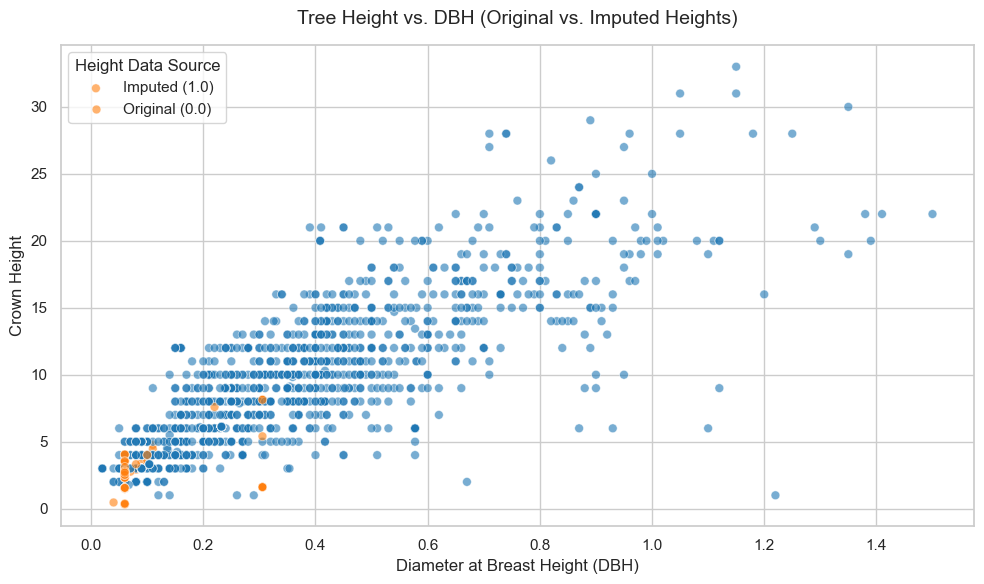

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fill any NaNs in the flag column with 0.0 (assuming non-imputed trees are 0 or NaN)
# and convert to a string so Seaborn treats it as two distinct categories (colors) 
# instead of a continuous gradient map.
df_plot = df_cleaned.copy()
df_plot['height_imputed_flag'] = df_plot['height_imputed_flag'].fillna(0.0).astype(str)

# 2. Set up the visual style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create the scatter plot
# Using alpha=0.6 makes the dots slightly transparent so we can see overlapping points
sns.scatterplot(
    data=df_plot,
    x='DBH',
    y='CROWN_HEIGHT_interpolated',
    hue='height_imputed_flag',
    palette={'0.0': '#1f77b4', '1.0': '#ff7f0e'}, # Blue for real, Orange for imputed
    alpha=0.6,
    s=40 # Dot size
)

# 4. Add clear labels and a title
plt.title('Tree Height vs. DBH (Original vs. Imputed Heights)', fontsize=14, pad=15)
plt.xlabel('Diameter at Breast Height (DBH)', fontsize=12)
plt.ylabel('Crown Height', fontsize=12)

# 5. Clean up the legend
plt.legend(title='Height Data Source', labels=['Imputed (1.0)', 'Original (0.0)'])

# 6. Show the plot
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd
import numpy as np

# 1. Make a safe copy of the dataframe
df_cleaned = df_cleaned.copy()

# 2. Fix Eastings: Find where they are 'inf' and replace with X
# np.isinf() safely finds both positive and negative infinity
mask_easting_1 = np.isinf(df_cleaned['EXTENT_EASTING_1'])
df_cleaned.loc[mask_easting_1, 'EXTENT_EASTING_1'] = df_cleaned.loc[mask_easting_1, 'X']

# Assuming you also have an EXTENT_EASTING_2 column with the same issue
if 'EXTENT_EASTING_2' in df_cleaned.columns:
    mask_easting_2 = np.isinf(df_cleaned['EXTENT_EASTING_2'])
    df_cleaned.loc[mask_easting_2, 'EXTENT_EASTING_2'] = df_cleaned.loc[mask_easting_2, 'X']

# 3. Fix Northings: Find where they are 'inf' and replace with Y
mask_northing_1 = np.isinf(df_cleaned['EXTENT_NORTHING_1'])
df_cleaned.loc[mask_northing_1, 'EXTENT_NORTHING_1'] = df_cleaned.loc[mask_northing_1, 'Y']

if 'EXTENT_NORTHING_2' in df_cleaned.columns:
    mask_northing_2 = np.isinf(df_cleaned['EXTENT_NORTHING_2'])
    df_cleaned.loc[mask_northing_2, 'EXTENT_NORTHING_2'] = df_cleaned.loc[mask_northing_2, 'Y']

# 4. Verification Check
cols_to_view = [
    'OBJECTID', 'COMMON_NAME', 'X', 'Y', 
    'EXTENT_EASTING_1', 'EXTENT_NORTHING_1'
]

# Let's look at those specific IDs you shared to confirm the fix
target_ids = [26651097, 26651098, 26651099, 26651100, 26651101, 26651102, 26651103, 26651111]
fixed_rows = df_cleaned[df_cleaned['OBJECTID'].isin(target_ids)]

print("--- Fixed Extent Coordinates ---")
display(fixed_rows[cols_to_view])

# Count how many 'inf' values are left overall
remaining_infs = np.isinf(df_cleaned[['EXTENT_EASTING_1', 'EXTENT_NORTHING_1']]).sum().sum()
print(f"\nTotal 'inf' values remaining in dataset: {remaining_infs}")

--- Fixed Extent Coordinates ---


,OBJECTID,COMMON_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1
41306,26651097,NaN,361198.32,171424.12,0.0,0.0
41307,26651098,Dawn Redwood,361187.90,171385.73,0.0,0.0
41308,26651099,Dawn Redwood,360949.52,171392.37,0.0,0.0
41309,26651100,Oak,361129.85,171346.23,0.0,0.0
41310,26651101,Silver Birch,361036.59,171472.74,0.0,0.0
41311,26651102,Silver Birch,361042.05,171460.09,0.0,0.0
41312,26651103,Dawn Redwood,361017.49,171313.08,0.0,0.0
41320,26651111,Ironwood,361000.02,171453.89,0.0,0.0



Total 'inf' values remaining in dataset: 0


In [55]:
df_cleaned

,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,DBH,CROWN_AREA_COMPLETE,Data Source,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag
130,26609482,Eugene Street,358778.42,173631.65,358778.42,173631.65,358778.42,173631.65,Betula pendula,Silver Birch,Silver birch,Betula pendula,0.060000,3.593897,Original,deciduous,3.580900,1.0
131,26609483,Eugene Street,358769.66,173620.75,358769.66,173620.75,358769.66,173620.75,Betula utilis,Birch,Himalayan birch,Betula utilis,0.320000,10.000000,Original,deciduous,8.000000,0.0
391,26609746,The Horsefair,359249.26,173476.59,359249.26,173476.59,359249.26,173476.59,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.500000,150.050000,Original,deciduous,14.000000,0.0
392,26609747,The Horsefair,359262.25,173477.53,359262.25,173477.53,359262.25,173477.53,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
393,26609748,The Horsefair,359276.98,173478.16,359276.98,173478.16,359276.98,173478.16,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54715,26664659,Ludlow Close Park,359657.38,174083.13,359657.38,174083.13,359657.38,174083.13,Prunus serrula Tibetica,Cherry,Cherry,Prunus serrula Tibetica,0.305455,42.839905,Imputed,other,5.404839,1.0
54971,26664915,Halston Drive Amenity Land,359699.06,173978.78,359699.06,173978.78,359699.06,173978.78,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.400000,150.050000,Original,deciduous,10.000000,0.0
54972,26664916,Halston Drive Amenity Land,359667.49,173958.53,359667.49,173958.53,359667.49,173958.53,Betula pendula,Birch,Silver birch,Betula pendula,0.520000,150.050000,Original,deciduous,11.000000,0.0
54973,26664917,Halston Drive Amenity Land,359666.82,173950.79,359666.82,173950.79,359666.82,173950.79,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.440000,150.050000,Original,deciduous,12.000000,0.0


In [56]:
df_cleaned.to_csv('FINAL_MERGED_TREE_DATASET.csv')

In [57]:
# Count how many of each category exist in 'tree_group'
# dropna=False ensures we also see if any trees are completely missing a group
group_counts = df_cleaned['tree_group'].value_counts(dropna=False)

print("--- Tree Group Breakdown ---")
print(group_counts)

# Optional: If you want to see it as a percentage instead of raw numbers
group_percentages = df_cleaned['tree_group'].value_counts(normalize=True, dropna=False) * 100

print("\n--- Tree Group Percentages ---")
print(group_percentages.round(2).astype(str) + '%')

--- Tree Group Breakdown ---
tree_group
deciduous    1290
evergreen      59
other          48
Name: count, dtype: int64

--- Tree Group Percentages ---
tree_group
deciduous    92.34%
evergreen     4.22%
other         3.44%
Name: proportion, dtype: object


In [58]:
# 1. Filter the dataset for trees where the group is 'Other'
# (Using .str.lower() == 'other' makes it bulletproof against 'Other', 'other', or 'OTHER')
mask_other = df_cleaned['tree_group'].astype(str).str.lower() == 'other'
df_other = df_cleaned[mask_other]

# 2. Print the total count
print(f"Total trees categorized as 'Other': {len(df_other)}\n")

# 3. Define the most useful columns to look at
cols_to_view = [
    'OBJECTID', 
    'COMMON_NAME',
    'FULL_COMMON_NAME', 
    'LATIN_NAME', 
    'tree_group', 
    'CROWN_HEIGHT_interpolated', 
    'CROWN_AREA_COMPLETE'
]

# 4. Display the rows (showing up to 50 so you can scroll through them)
# If there are a lot, you might want to use .head(20) instead!
display(df_other[cols_to_view])

Total trees categorized as 'Other': 48



,OBJECTID,COMMON_NAME,FULL_COMMON_NAME,LATIN_NAME,tree_group,CROWN_HEIGHT_interpolated,CROWN_AREA_COMPLETE
1403,26610773,NaN,NaN,Platanus x acerifolia,other,16.000000,263.567164
5951,26615410,NaN,Dawn redwood,Metasequoia glyptostroboides,other,2.931440,4.978244
5953,26615412,NaN,Dawn redwood,Metasequoia glyptostroboides,other,2.931440,4.978244
5955,26615414,NaN,Dawn redwood,Metasequoia glyptostroboides,other,2.931440,4.978244
5958,26615417,NaN,Dawn redwood,Metasequoia glyptostroboides,other,2.931440,4.978244
5960,26615419,NaN,American sweetgum,Liquidambar styraciflua ’Worp',other,2.931440,4.978244
5963,26615422,NaN,American sweetgum,Liquidambar styraciflua ’Worp',other,2.931440,4.978244
5965,26615424,NaN,American sweetgum,Liquidambar styraciflua ’Worp',other,2.931440,4.978244
5966,26615425,NaN,Dawn redwood,Metasequoia glyptostroboides,other,2.931440,4.978244
5968,26615427,NaN,American sweetgum,Liquidambar styraciflua ’Worp',other,2.931440,4.978244


Found 18 unique species to plot.



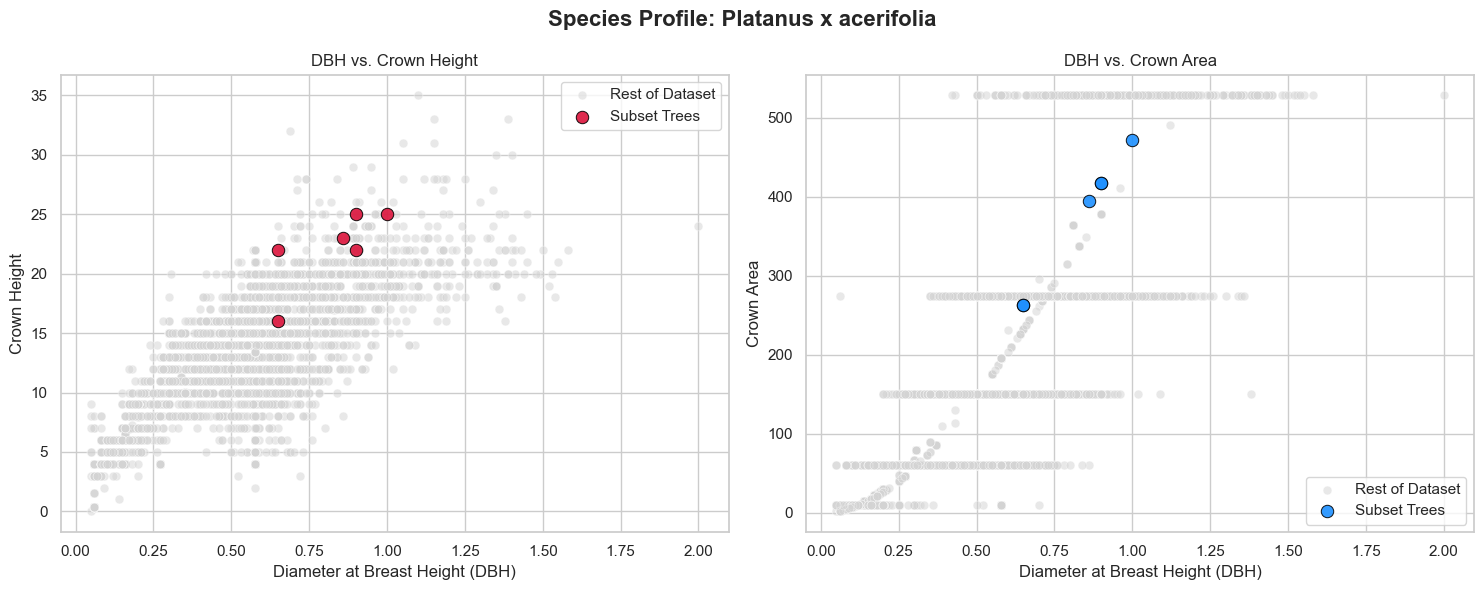

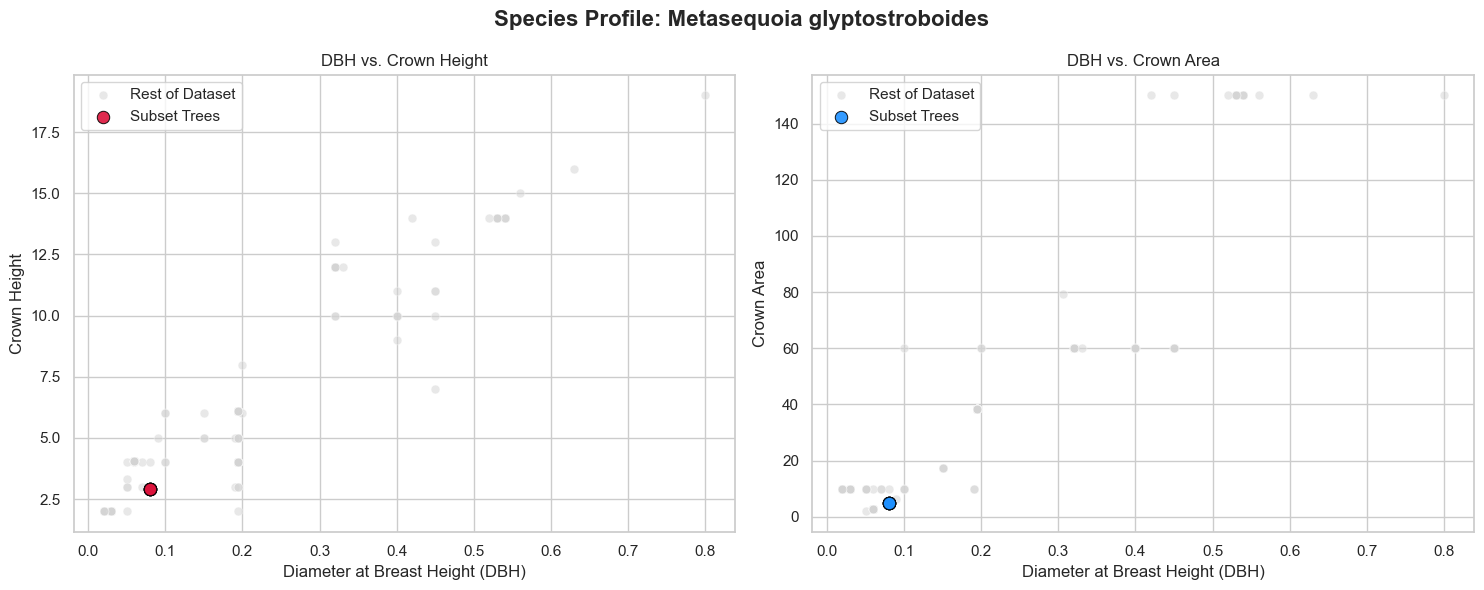

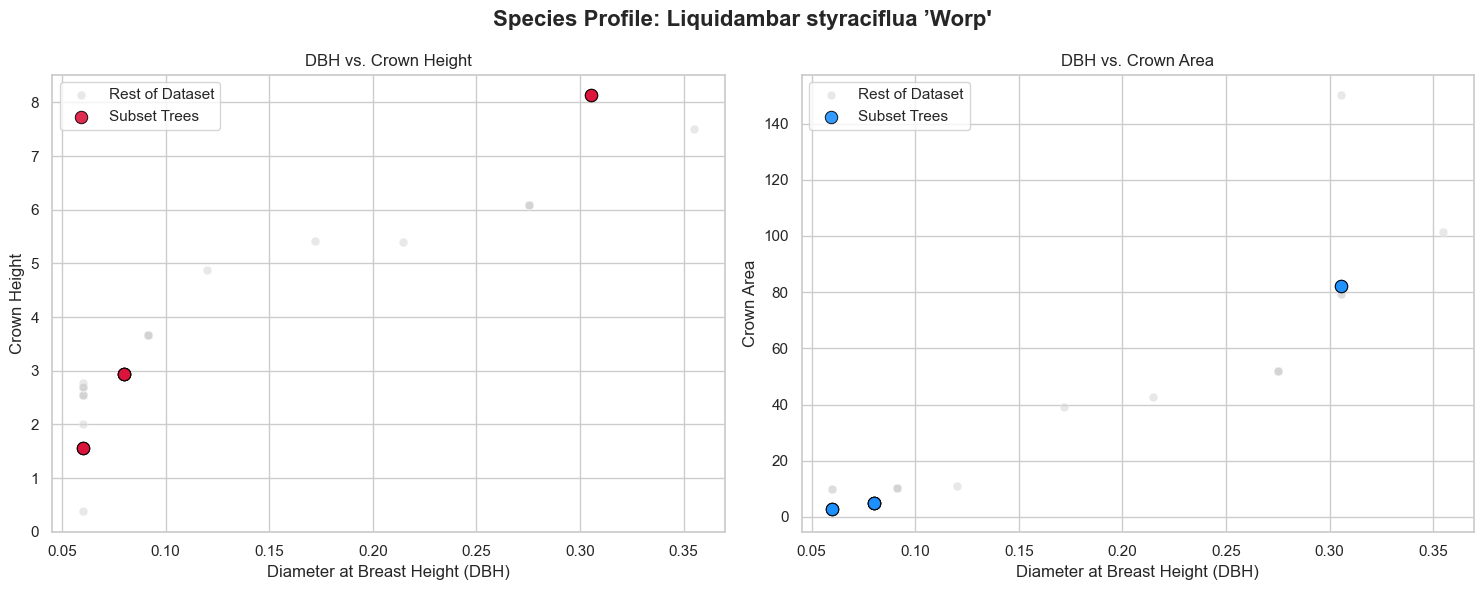

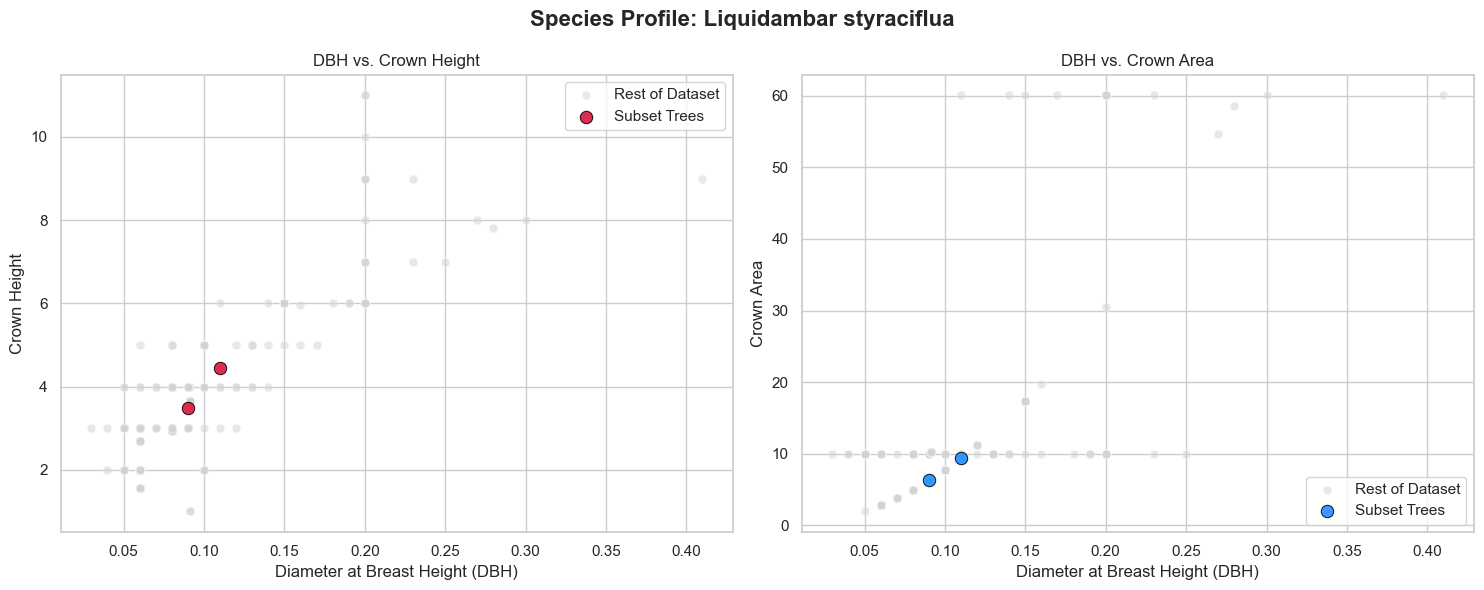

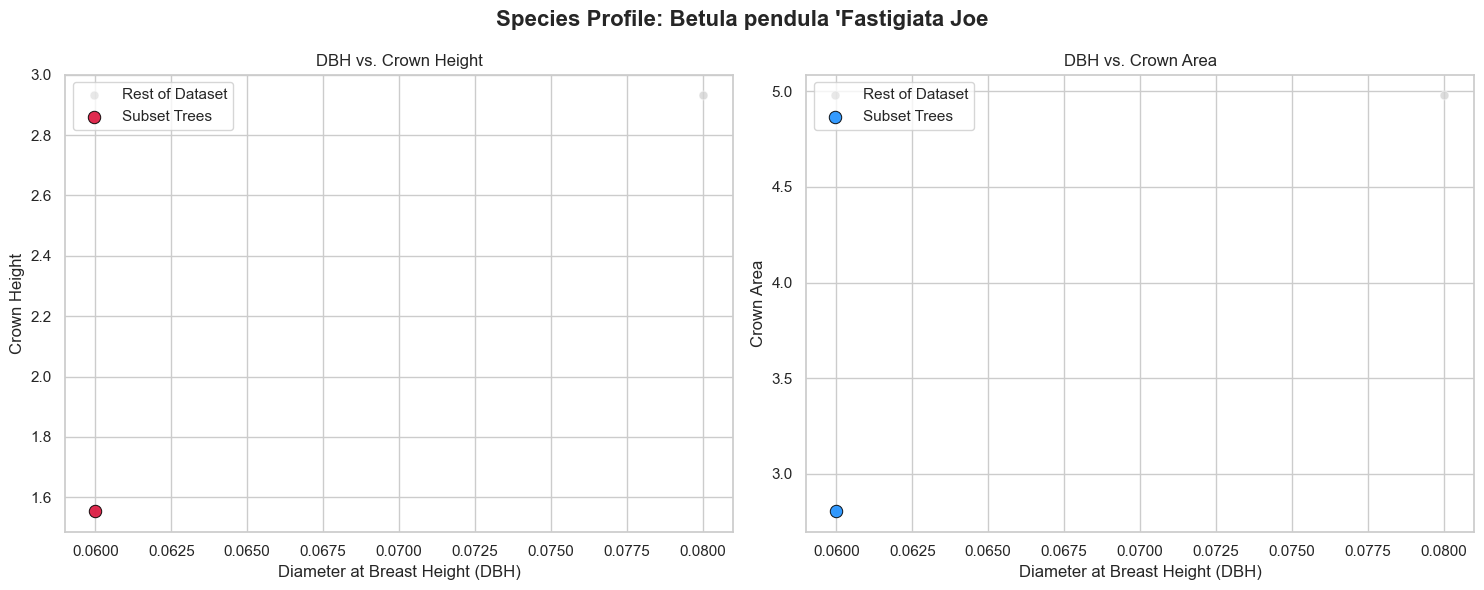

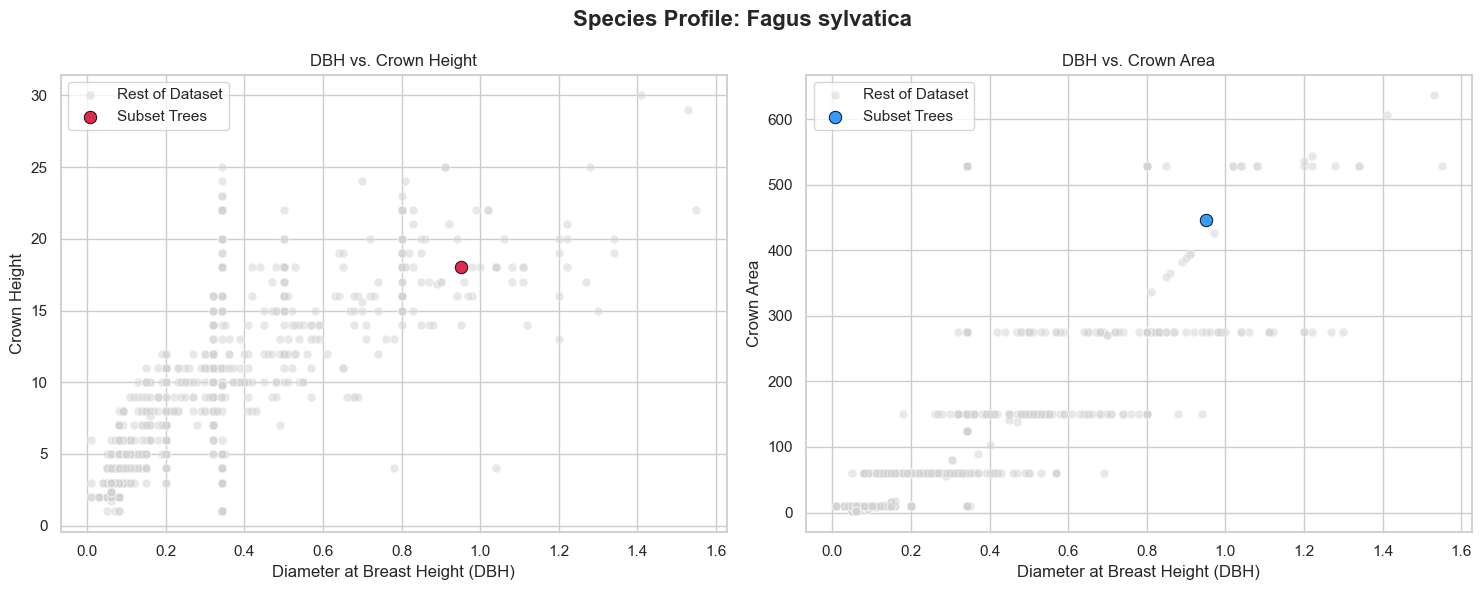

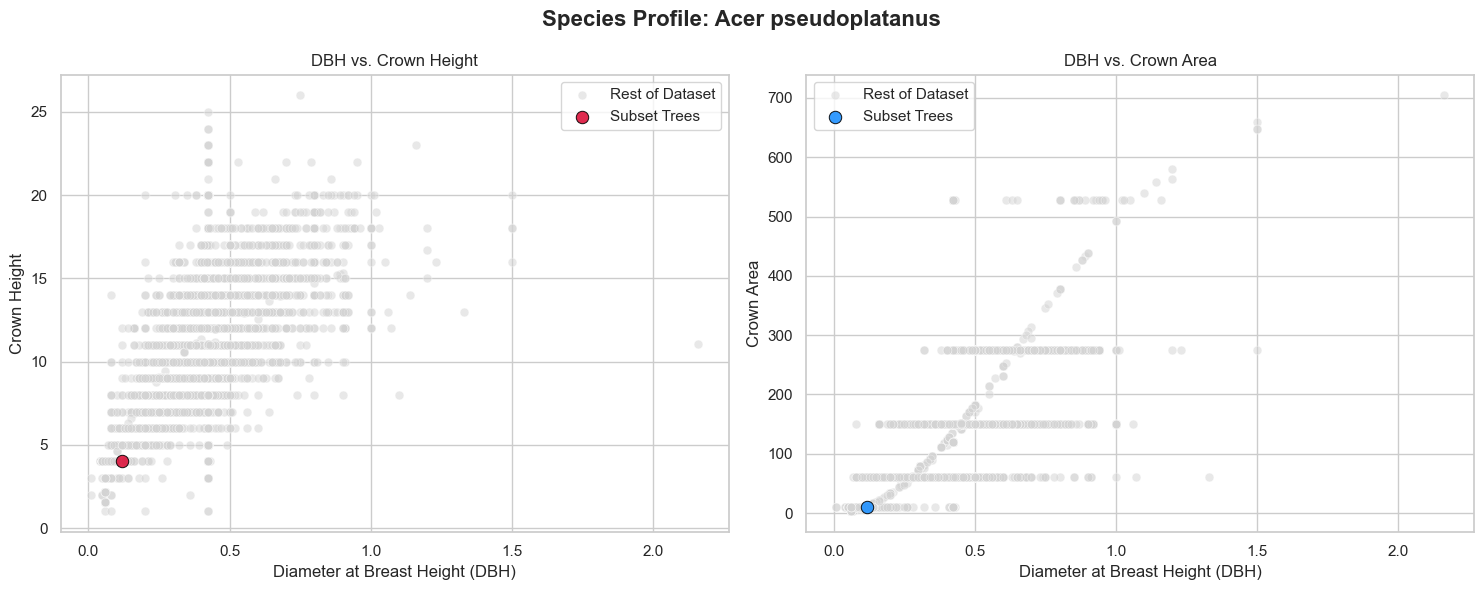

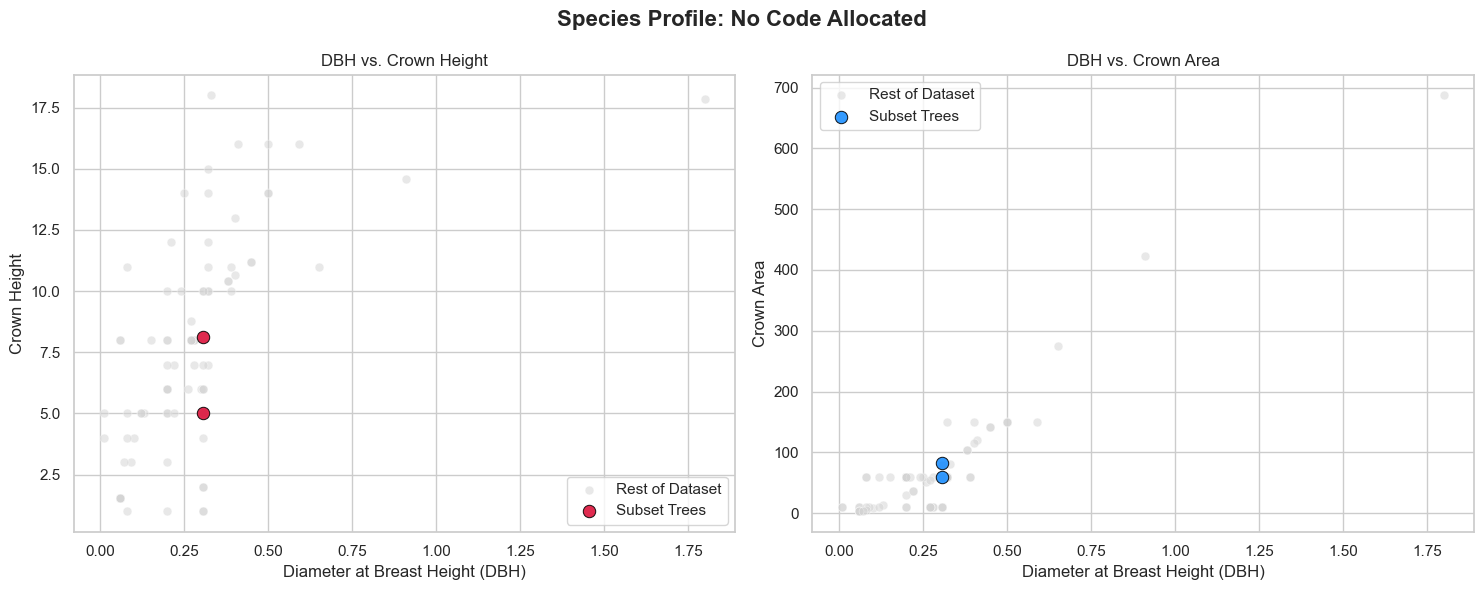

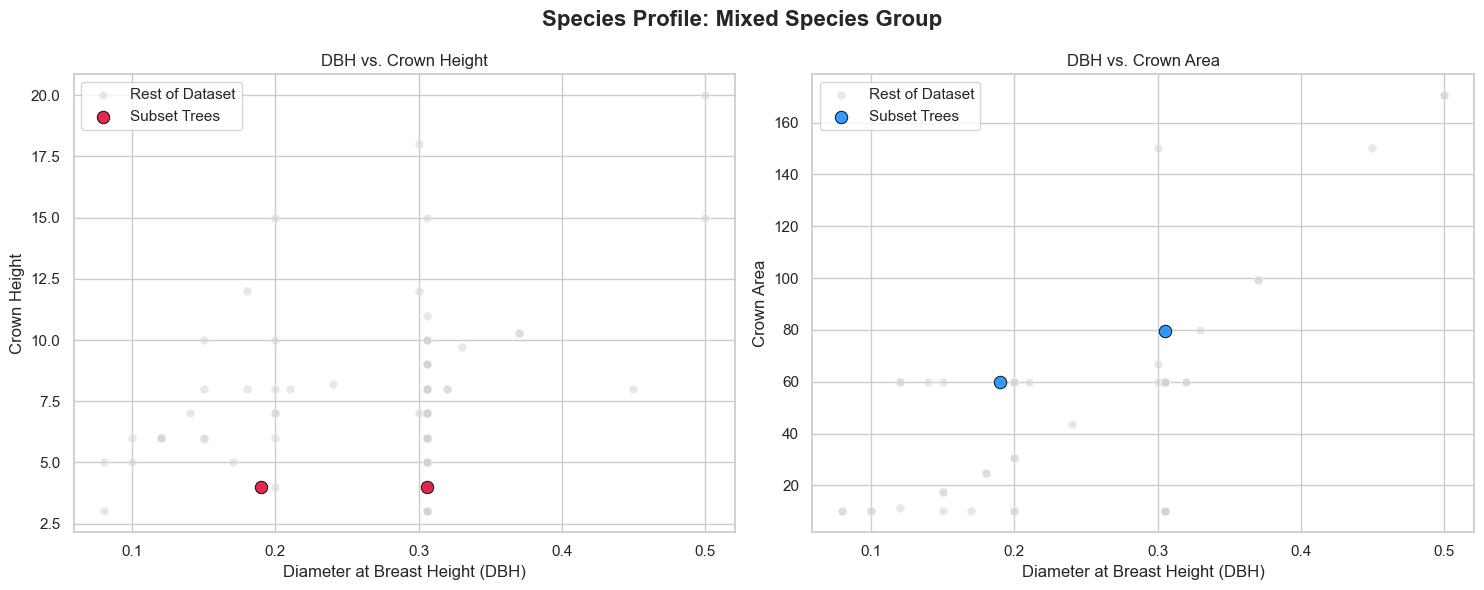

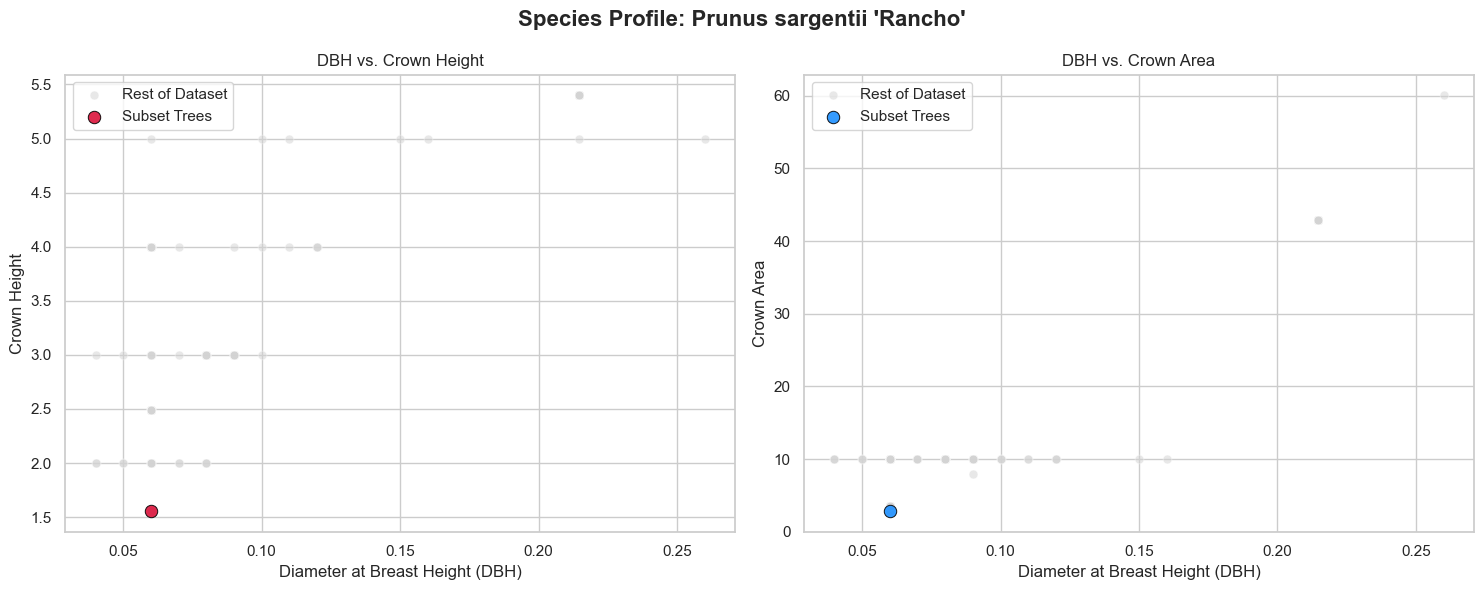

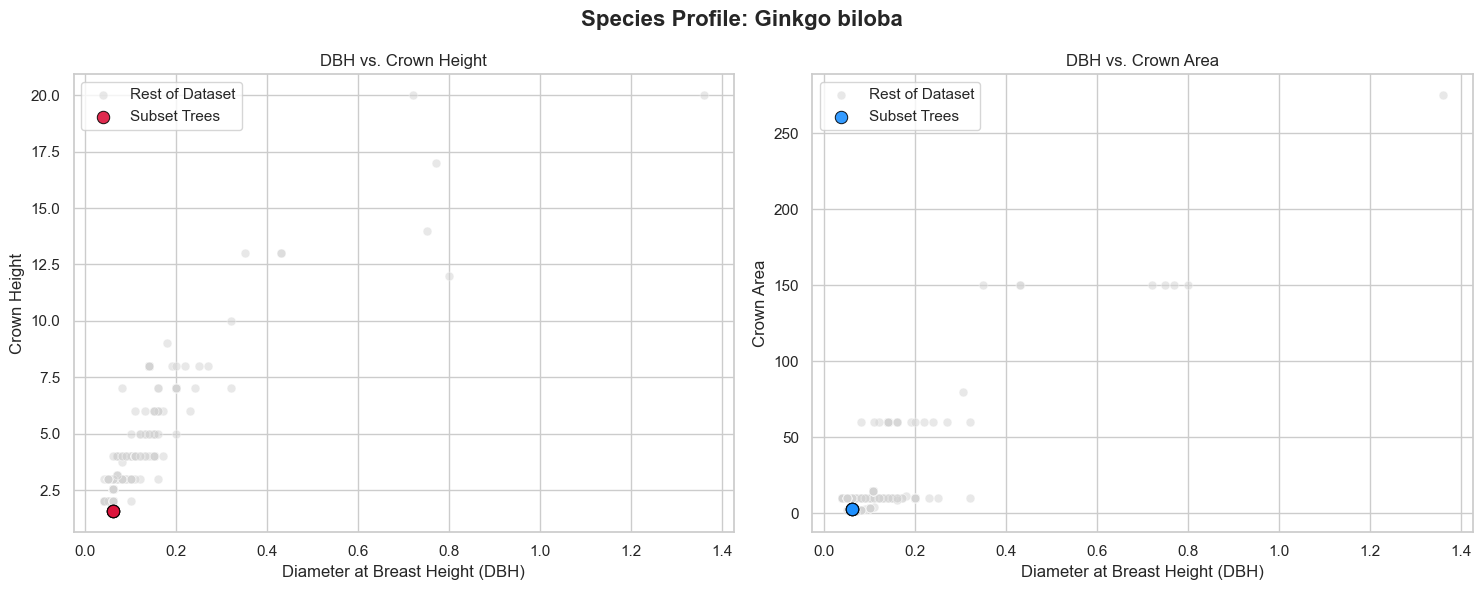

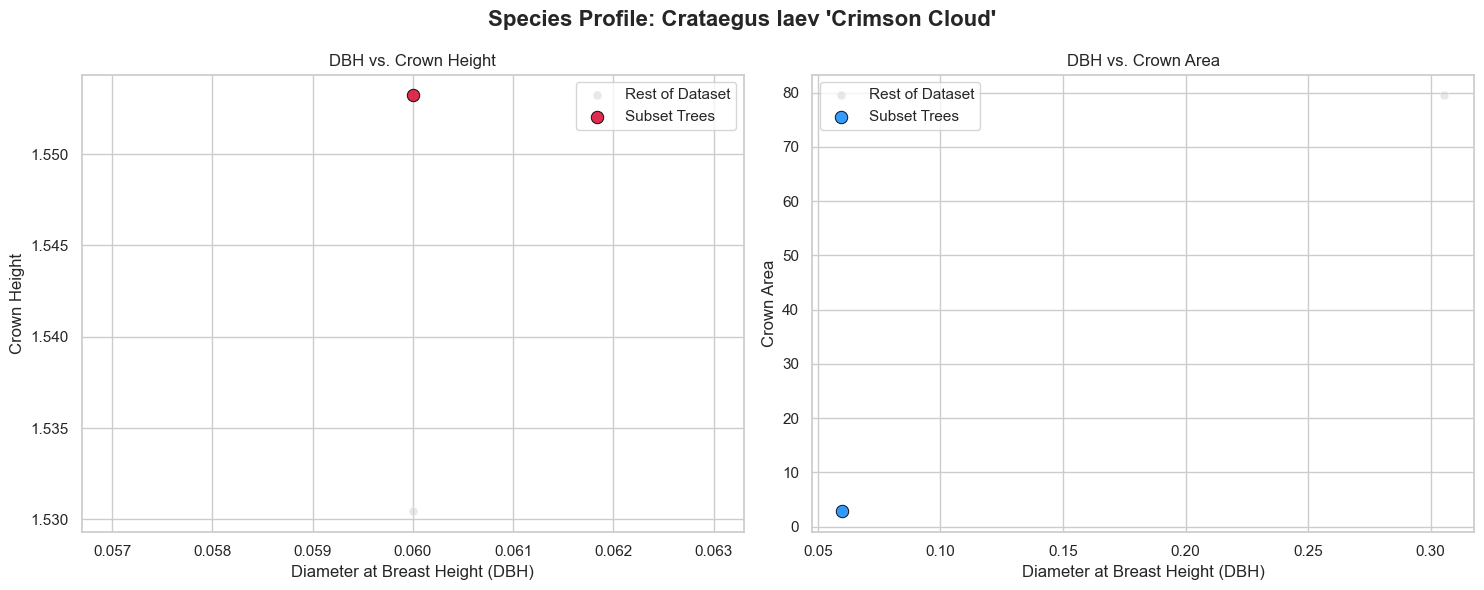

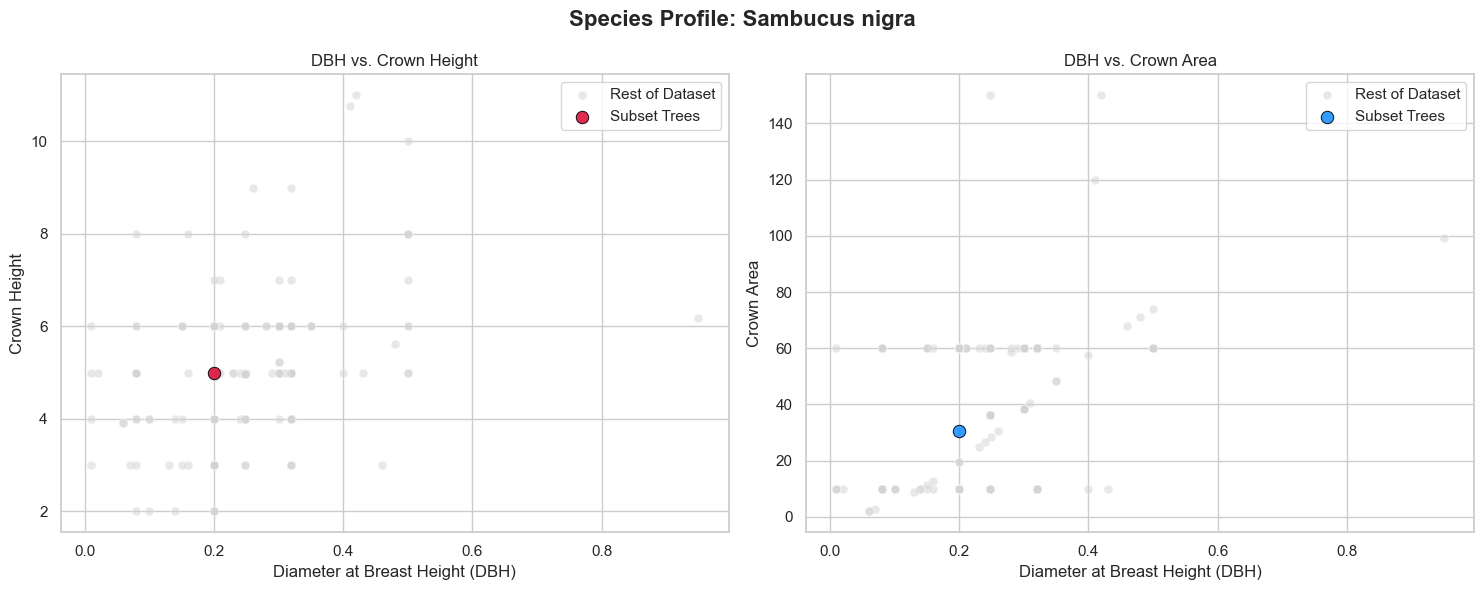

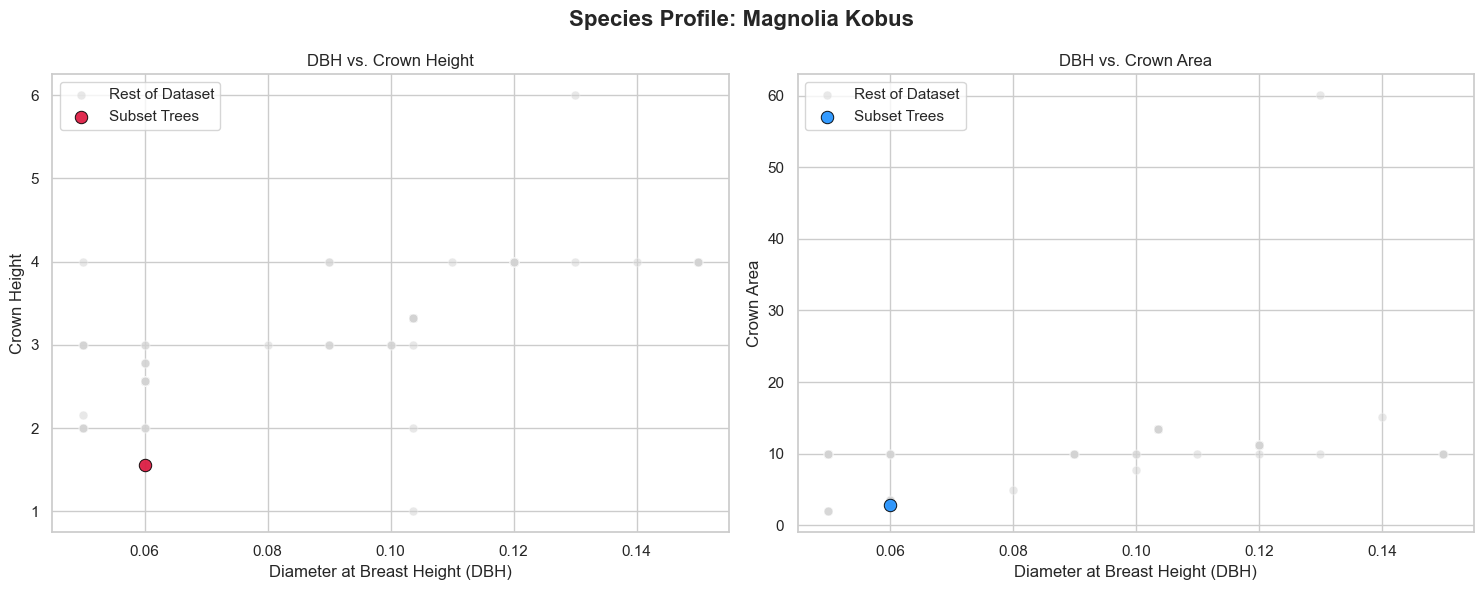

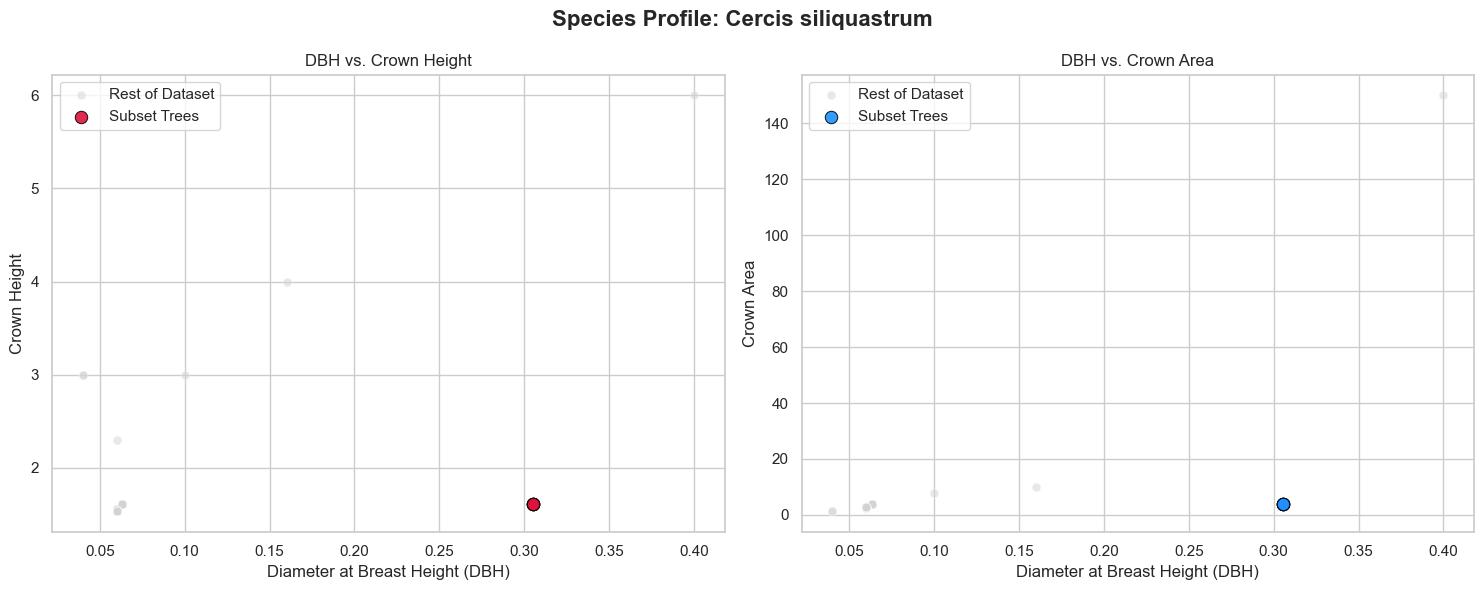

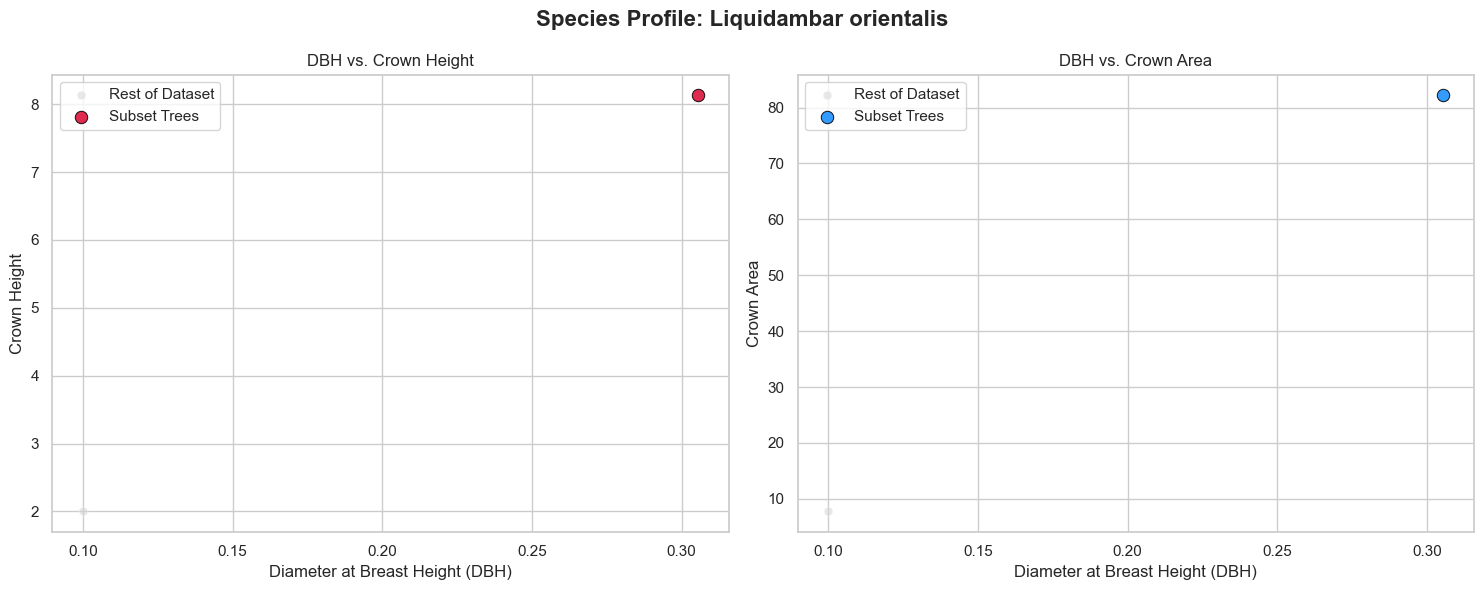

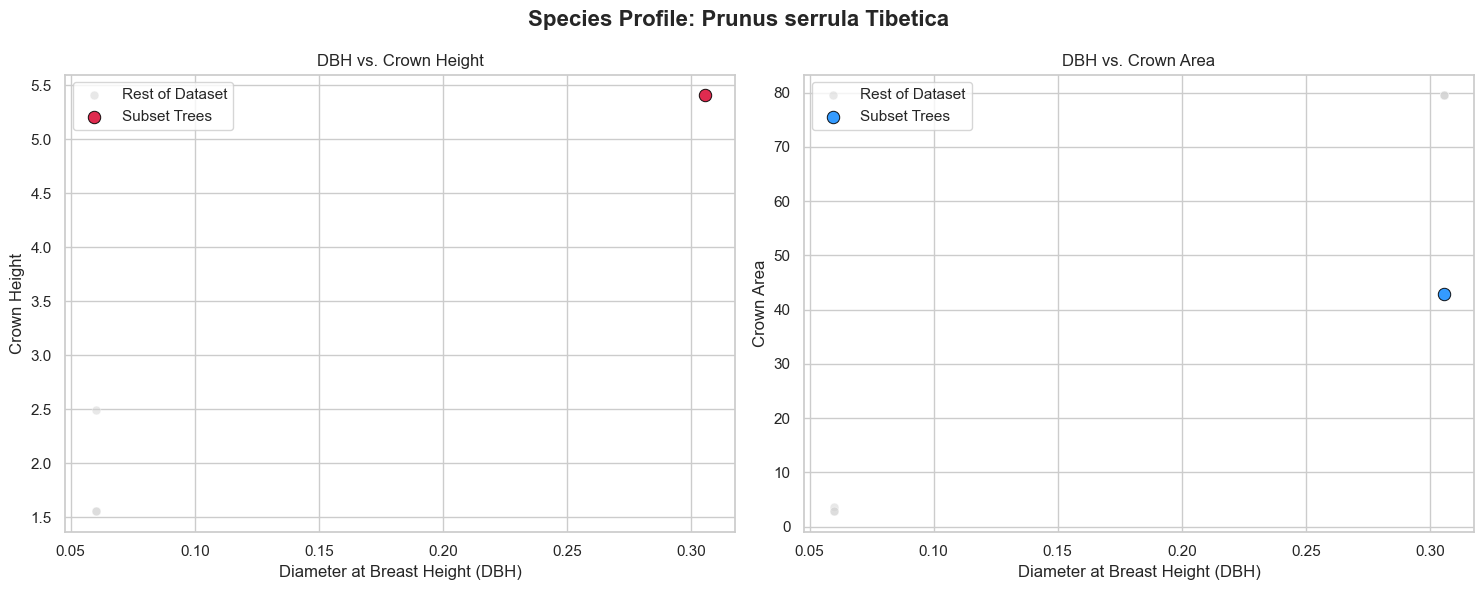

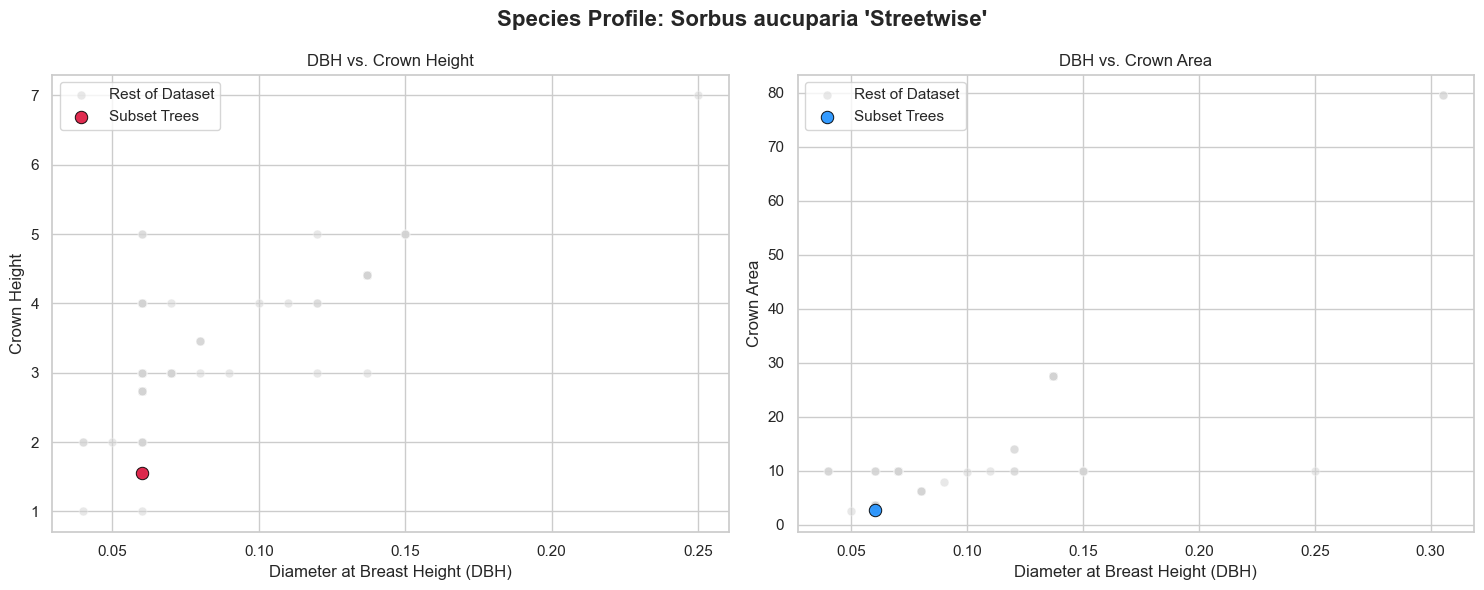

In [59]:
# 1. Define which subset you are plotting (change this to df_final_subset if needed!)
df_subset = df_other.copy() 

# 2. Find all the unique species in this subset (ignoring blanks)
target_species = df_subset['LATIN_NAME'].dropna().unique()

print(f"Found {len(target_species)} unique species to plot.\n")

# Safety feature: If there are tons of species, maybe just plot the first 10 so it doesn't crash your notebook!
# target_species = target_species[:10] 

# 3. Loop through each species and create a plot pair
for species in target_species:
    
    # -- A. Isolate the data for THIS specific species --
    # 1. Get the trees from the subset
    subset_sp = df_subset[df_subset['LATIN_NAME'] == species]
    
    # 2. Get the OTHER trees of this species from the massive combined dataset
    combined_sp_all = df_combined[df_combined['LATIN_NAME'] == species]
    # Filter OUT the ones that are already in our subset so they don't get plotted twice!
    combined_sp_rest = combined_sp_all[~combined_sp_all['OBJECTID'].isin(subset_sp['OBJECTID'])]
    
    # -- B. Set up the visual canvas (1 row, 2 columns) --
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Species Profile: {species}', fontsize=16, fontweight='bold')
    
    # --- PLOT 1: DBH vs CROWN HEIGHT ---
    # Plot the "rest of the dataset" first so it acts as a muted background shadow
    sns.scatterplot(
        ax=axes[0], data=combined_sp_rest, x='DBH', y='CROWN_HEIGHT_interpolated',
        color='lightgray', label='Rest of Dataset', alpha=0.5, s=40
    )
    # Plot the subset trees on top in a bold color
    sns.scatterplot(
        ax=axes[0], data=subset_sp, x='DBH', y='CROWN_HEIGHT_interpolated',
        color='crimson', label='Subset Trees', alpha=0.9, s=80, edgecolor='black'
    )
    axes[0].set_title('DBH vs. Crown Height')
    axes[0].set_xlabel('Diameter at Breast Height (DBH)')
    axes[0].set_ylabel('Crown Height')
    axes[0].legend()
    
    # --- PLOT 2: DBH vs CROWN AREA ---
    # Background data
    sns.scatterplot(
        ax=axes[1], data=combined_sp_rest, x='DBH', y='CROWN_AREA_COMPLETE',
        color='lightgray', label='Rest of Dataset', alpha=0.5, s=40
    )
    # Subset data (using a different bold color for area)
    sns.scatterplot(
        ax=axes[1], data=subset_sp, x='DBH', y='CROWN_AREA_COMPLETE',
        color='dodgerblue', label='Subset Trees', alpha=0.9, s=80, edgecolor='black'
    )
    axes[1].set_title('DBH vs. Crown Area')
    axes[1].set_xlabel('Diameter at Breast Height (DBH)')
    axes[1].set_ylabel('Crown Area')
    axes[1].legend()
    
    # Clean up the layout and display this species' pair of plots
    plt.tight_layout()
    plt.show()

In [60]:
# 1. Define the specific trees we want to target
target_ids = [26651091, 26651120]

# 2. Create the mask to locate them
mask_targets = df_cleaned['OBJECTID'].isin(target_ids)

# 3. Inject the exact values for height and area
df_cleaned.loc[mask_targets, 'CROWN_HEIGHT_interpolated'] = 1.553224
df_cleaned.loc[mask_targets, 'CROWN_AREA_COMPLETE'] = 2.804590

# 4. Quick Verification
cols_to_view = ['OBJECTID', 'COMMON_NAME', 'CROWN_HEIGHT_interpolated', 'CROWN_AREA_COMPLETE']
print("--- Targeted Trees Updated ---")
display(df_cleaned[mask_targets][cols_to_view])

--- Targeted Trees Updated ---


,OBJECTID,COMMON_NAME,CROWN_HEIGHT_interpolated,CROWN_AREA_COMPLETE
41300,26651091,NaN,1.553224,2.80459
41329,26651120,NaN,1.553224,2.80459


In [61]:
# 1. Create a "Lookup Dictionary" from trees that ALREADY have a common name
# We drop rows missing a common name, group by Latin name, and grab the first Common name we see
latin_to_common_map = df_cleaned.dropna(subset=['COMMON_NAME']).groupby('LATIN_NAME')['COMMON_NAME'].first()

# 2. Count missing common names before the fix
missing_before = df_cleaned['COMMON_NAME'].isna().sum()

# 3. Fill the NaNs using the map
# .fillna() ensures we ONLY overwrite the blanks. 
# It looks at the Latin name for that row, checks our map, and slots in the Common name.
df_cleaned['COMMON_NAME'] = df_cleaned['COMMON_NAME'].fillna(df_cleaned['LATIN_NAME'].map(latin_to_common_map))

# 4. Verification Check
missing_after = df_cleaned['COMMON_NAME'].isna().sum()

print("--- Common Name Imputation ---")
print(f"Missing before: {missing_before}")
print(f"Missing after:  {missing_after}")
print(f"Successfully filled: {missing_before - missing_after} names!")

# 5. Catch any stubborn leftovers
# If any are still NaN, it means their Latin name NEVER had a common name anywhere in the dataset
if missing_after > 0:
    still_missing_species = df_cleaned[df_cleaned['COMMON_NAME'].isna()]['LATIN_NAME'].dropna().unique()
    print(f"\n⚠️ Note: {missing_after} trees still lack a common name because their Latin name had no translation anywhere in the dataset.")
    print(f"Latin names still missing a common match: {still_missing_species}")

--- Common Name Imputation ---
Missing before: 42
Missing after:  20
Successfully filled: 22 names!

⚠️ Note: 20 trees still lack a common name because their Latin name had no translation anywhere in the dataset.
Latin names still missing a common match: ["Liquidambar styraciflua ’Worp'" "Betula pendula 'Fastigiata Joe"
 'No Code Allocated' 'Mixed Species Group' "Prunus sargentii 'Rancho'"
 "Crataegus laev 'Crimson Cloud'" 'Magnolia Kobus'
 'Liquidambar orientalis' "Sorbus aucuparia 'Streetwise'"]


In [62]:
# 1. Count how many are missing before this step
missing_before_fallback = df_cleaned['COMMON_NAME'].isna().sum()

# 2. Fill the remaining blanks with the FULL_COMMON_NAME column
df_cleaned['COMMON_NAME'] = df_cleaned['COMMON_NAME'].fillna(df_cleaned['FULL_COMMON_NAME'])

# 3. Verification Check
missing_after_fallback = df_cleaned['COMMON_NAME'].isna().sum()

print("--- Fallback Imputation: FULL_COMMON_NAME ---")
print(f"Missing before: {missing_before_fallback}")
print(f"Missing after:  {missing_after_fallback}")
print(f"Successfully filled: {missing_before_fallback - missing_after_fallback} names!")

# 4. Final check for any truly stubborn rows
if missing_after_fallback > 0:
    print(f"\n⚠️ Note: {missing_after_fallback} trees are STILL missing a common name.")
    print("These trees likely have NaN in both the COMMON_NAME and FULL_COMMON_NAME columns.")

--- Fallback Imputation: FULL_COMMON_NAME ---
Missing before: 20
Missing after:  7
Successfully filled: 13 names!

⚠️ Note: 7 trees are STILL missing a common name.
These trees likely have NaN in both the COMMON_NAME and FULL_COMMON_NAME columns.


In [63]:
# 1. Create a mask to find the rows where COMMON_NAME is still NaN
mask_still_missing = df_cleaned['COMMON_NAME'].isna()

# 2. Extract those specific rows
df_stubborn_trees = df_cleaned[mask_still_missing]

# 3. Define the most helpful columns to view for text-based detective work
cols_to_view = [
    'OBJECTID', 
    'SITE_NAME', 
    'LATIN_NAME', 
    'FULL_COMMON_NAME', 
    'COMMON_NAME', 
    'TREE_SPECIES',
    'tree_group'
]

# 4. Display the results
print(f"--- Showing the {len(df_stubborn_trees)} trees still missing a Common Name ---")
display(df_stubborn_trees[cols_to_view])

--- Showing the 7 trees still missing a Common Name ---


,OBJECTID,SITE_NAME,LATIN_NAME,FULL_COMMON_NAME,COMMON_NAME,TREE_SPECIES,tree_group
14858,26624438,Drummond Road,Betula pendula 'Fastigiata Joe,NaN,NaN,Betula pendula 'Fastigiata Joe,other
24891,26634543,Newfoundland Street,No Code Allocated,NaN,NaN,No Code Allocated,other
27566,26637251,Fishponds Church of England Academy,Mixed Species Group,NaN,NaN,Mixed Species Group,other
27572,26637257,Fishponds Church of England Academy,Mixed Species Group,NaN,NaN,Mixed Species Group,other
38361,26648124,Portland Square Park,Crataegus laev 'Crimson Cloud',NaN,NaN,Crataegus laev 'Crimson Cloud',other
52989,26662909,Shapcott Close (SH),No Code Allocated,NaN,NaN,No Code Allocated,other
54974,26664918,Halston Drive Amenity Land,Sorbus aucuparia 'Streetwise',NaN,NaN,Sorbus aucuparia 'Streetwise',other


In [64]:
df_cleaned

,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,DBH,CROWN_AREA_COMPLETE,Data Source,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag
130,26609482,Eugene Street,358778.42,173631.65,358778.42,173631.65,358778.42,173631.65,Betula pendula,Silver Birch,Silver birch,Betula pendula,0.060000,3.593897,Original,deciduous,3.580900,1.0
131,26609483,Eugene Street,358769.66,173620.75,358769.66,173620.75,358769.66,173620.75,Betula utilis,Birch,Himalayan birch,Betula utilis,0.320000,10.000000,Original,deciduous,8.000000,0.0
391,26609746,The Horsefair,359249.26,173476.59,359249.26,173476.59,359249.26,173476.59,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.500000,150.050000,Original,deciduous,14.000000,0.0
392,26609747,The Horsefair,359262.25,173477.53,359262.25,173477.53,359262.25,173477.53,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
393,26609748,The Horsefair,359276.98,173478.16,359276.98,173478.16,359276.98,173478.16,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54715,26664659,Ludlow Close Park,359657.38,174083.13,359657.38,174083.13,359657.38,174083.13,Prunus serrula Tibetica,Cherry,Cherry,Prunus serrula Tibetica,0.305455,42.839905,Imputed,other,5.404839,1.0
54971,26664915,Halston Drive Amenity Land,359699.06,173978.78,359699.06,173978.78,359699.06,173978.78,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.400000,150.050000,Original,deciduous,10.000000,0.0
54972,26664916,Halston Drive Amenity Land,359667.49,173958.53,359667.49,173958.53,359667.49,173958.53,Betula pendula,Birch,Silver birch,Betula pendula,0.520000,150.050000,Original,deciduous,11.000000,0.0
54973,26664917,Halston Drive Amenity Land,359666.82,173950.79,359666.82,173950.79,359666.82,173950.79,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.440000,150.050000,Original,deciduous,12.000000,0.0


In [65]:
# 1. Grab the IDs of all 7 stubborn trees from our previous step
# (This assumes df_stubborn_trees is still in your memory)
stubborn_ids = df_stubborn_trees['OBJECTID'].tolist()

# 2. Set ALL 7 of them to 'Deciduous' in one swift move
df_cleaned.loc[df_cleaned['OBJECTID'].isin(stubborn_ids), 'tree_group'] = 'Deciduous'

# 3. Surgically inject the specific Common Names for the 3 you identified
df_cleaned.loc[df_cleaned['OBJECTID'] == 26624438, 'COMMON_NAME'] = 'Silver Birch'
df_cleaned.loc[df_cleaned['OBJECTID'] == 26648124, 'COMMON_NAME'] = 'Hawthorn'
df_cleaned.loc[df_cleaned['OBJECTID'] == 26664918, 'COMMON_NAME'] = 'Rowan'

# 4. Final Verification Check
cols_to_view = ['OBJECTID', 'COMMON_NAME', 'tree_group']

print("--- Final Manual Updates Applied ---")
display(df_cleaned[df_cleaned['OBJECTID'].isin(stubborn_ids)][cols_to_view])

# Optional: Check if we have ANY missing Common Names left in the entire dataset
final_missing = df_cleaned['COMMON_NAME'].isna().sum()
if final_missing == 0:
    print("\n✅ INCREDIBLE! Your entire dataset now has 100% complete Common Names and Tree Groups!")
else:
    print(f"\n⚠️ Almost there! You still have {final_missing} missing common names left.")

--- Final Manual Updates Applied ---


,OBJECTID,COMMON_NAME,tree_group
14858,26624438,Silver Birch,Deciduous
24891,26634543,NaN,Deciduous
27566,26637251,NaN,Deciduous
27572,26637257,NaN,Deciduous
38361,26648124,Hawthorn,Deciduous
52989,26662909,NaN,Deciduous
54974,26664918,Rowan,Deciduous



⚠️ Almost there! You still have 4 missing common names left.


In [66]:
df_cleaned

,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,DBH,CROWN_AREA_COMPLETE,Data Source,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag
130,26609482,Eugene Street,358778.42,173631.65,358778.42,173631.65,358778.42,173631.65,Betula pendula,Silver Birch,Silver birch,Betula pendula,0.060000,3.593897,Original,deciduous,3.580900,1.0
131,26609483,Eugene Street,358769.66,173620.75,358769.66,173620.75,358769.66,173620.75,Betula utilis,Birch,Himalayan birch,Betula utilis,0.320000,10.000000,Original,deciduous,8.000000,0.0
391,26609746,The Horsefair,359249.26,173476.59,359249.26,173476.59,359249.26,173476.59,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.500000,150.050000,Original,deciduous,14.000000,0.0
392,26609747,The Horsefair,359262.25,173477.53,359262.25,173477.53,359262.25,173477.53,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
393,26609748,The Horsefair,359276.98,173478.16,359276.98,173478.16,359276.98,173478.16,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54715,26664659,Ludlow Close Park,359657.38,174083.13,359657.38,174083.13,359657.38,174083.13,Prunus serrula Tibetica,Cherry,Cherry,Prunus serrula Tibetica,0.305455,42.839905,Imputed,other,5.404839,1.0
54971,26664915,Halston Drive Amenity Land,359699.06,173978.78,359699.06,173978.78,359699.06,173978.78,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.400000,150.050000,Original,deciduous,10.000000,0.0
54972,26664916,Halston Drive Amenity Land,359667.49,173958.53,359667.49,173958.53,359667.49,173958.53,Betula pendula,Birch,Silver birch,Betula pendula,0.520000,150.050000,Original,deciduous,11.000000,0.0
54973,26664917,Halston Drive Amenity Land,359666.82,173950.79,359666.82,173950.79,359666.82,173950.79,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.440000,150.050000,Original,deciduous,12.000000,0.0


In [67]:
evergreen_set = {
    "Bay", "Box", "Cabbage Palm", "Cedar", "Chusan Palm", "Conifer", "Cypress", "Douglas Fir", "Eleagnus",
    "Eucalyptus", "Feijoa", "Fir", "Firethorn", "Hiba", "Hemlock", "Holly", "Juniper", "Laurel", "Monkey Puzzle",
    "Pine", "Pittosporum", "Redwood", "Scots Pine", "Spruce", "Strawberry Tree", "Wedding Cake Tree", "Yew"
}

# 2. Create a mask to isolate ONLY the trees currently labeled as 'Other'
mask_other = df_cleaned['tree_group'].astype(str).str.lower() == 'other'

# Count how many we are dealing with before the split
total_other = mask_other.sum()

# 3. Figure out which of these 'Other' trees belong in which new category
# .isin() checks if the Common Name exists in your evergreen_set
mask_is_evergreen = df_cleaned['COMMON_NAME'].isin(evergreen_set)

# Combine the masks to get our exact targets
# (Must be 'Other' AND in the evergreen set)
target_evergreen = mask_other & mask_is_evergreen 
# (Must be 'Other' AND NOT in the evergreen set -> the '~' symbol means NOT)
target_deciduous = mask_other & ~mask_is_evergreen 

# 4. Apply the new classifications
df_cleaned.loc[target_evergreen, 'tree_group'] = 'Evergreen'
df_cleaned.loc[target_deciduous, 'tree_group'] = 'Deciduous'

# 5. Verification Check
count_evergreen_new = target_evergreen.sum()
count_deciduous_new = target_deciduous.sum()

print("--- 'Other' Category Reclassification Complete ---")
print(f"Total 'Other' trees processed: {total_other}")
print(f"🌲 Reclassified as Evergreen:   {count_evergreen_new}")
print(f"🍂 Reclassified as Deciduous:   {count_deciduous_new}")

# Double check that no 'Other' trees remain
remaining_other = (df_cleaned['tree_group'].astype(str).str.lower() == 'other').sum()
if remaining_other == 0:
    print("\n✅ Success! The 'Other' category has been completely eliminated from your dataset.")
else:
    print(f"\n⚠️ Warning: {remaining_other} trees still have 'Other' as their group.")

--- 'Other' Category Reclassification Complete ---
Total 'Other' trees processed: 41
🌲 Reclassified as Evergreen:   0
🍂 Reclassified as Deciduous:   41

✅ Success! The 'Other' category has been completely eliminated from your dataset.


In [68]:
# 1. Define the only acceptable categories
valid_categories = ['Deciduous', 'Evergreen']

# 2. Find any rows that DO NOT match exactly
# .isin() checks for exact matches, and the '~' means "NOT"
mask_invalid = ~df_cleaned['tree_group'].isin(valid_categories)
df_invalid = df_cleaned[mask_invalid]

# 3. Print the final summary
print("--- Final Tree Group Validation ---")
print(df_cleaned['tree_group'].value_counts(dropna=False))

print("\n--- Outlier Check ---")
if len(df_invalid) == 0:
    print("✅ PERFECT MATCH! Every single tree is strictly 'Deciduous' or 'Evergreen'.")
else:
    print(f"⚠️ WAIT! There are {len(df_invalid)} trees with invalid or missing groups.")
    print("\nHere are the specific unique values causing the issue:")
    # Print the unique weird values so you know exactly what to fix
    print(df_invalid['tree_group'].unique())
    
    # Display the first few problematic rows
    cols_to_view = ['OBJECTID', 'COMMON_NAME', 'LATIN_NAME', 'tree_group']
    display(df_invalid[cols_to_view].head())

--- Final Tree Group Validation ---
tree_group
deciduous    1290
evergreen      59
Deciduous      48
Name: count, dtype: int64

--- Outlier Check ---
⚠️ WAIT! There are 1349 trees with invalid or missing groups.

Here are the specific unique values causing the issue:
['deciduous' 'evergreen']


,OBJECTID,COMMON_NAME,LATIN_NAME,tree_group
130,26609482,Silver Birch,Betula pendula,deciduous
131,26609483,Birch,Betula utilis,deciduous
391,26609746,Maple,Acer platanoides cv,deciduous
392,26609747,Maple,Acer platanoides cv,deciduous
393,26609748,Maple,Acer platanoides cv,deciduous


In [69]:
# 1. Replace 'Deciduous' with 'deciduous'
df_cleaned['tree_group'] = df_cleaned['tree_group'].replace('Deciduous', 'deciduous')

# Optional: If you also want 'Evergreen' to become 'evergreen' for total consistency, 
# you can run this instead to lowercase the entire column in one go:
# df_cleaned['tree_group'] = df_cleaned['tree_group'].str.lower()

# 2. Verification Check
print("--- Updated Tree Groups ---")
print(df_cleaned['tree_group'].value_counts(dropna=False))

--- Updated Tree Groups ---
tree_group
deciduous    1338
evergreen      59
Name: count, dtype: int64


In [70]:
df_cleaned

,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,DBH,CROWN_AREA_COMPLETE,Data Source,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag
130,26609482,Eugene Street,358778.42,173631.65,358778.42,173631.65,358778.42,173631.65,Betula pendula,Silver Birch,Silver birch,Betula pendula,0.060000,3.593897,Original,deciduous,3.580900,1.0
131,26609483,Eugene Street,358769.66,173620.75,358769.66,173620.75,358769.66,173620.75,Betula utilis,Birch,Himalayan birch,Betula utilis,0.320000,10.000000,Original,deciduous,8.000000,0.0
391,26609746,The Horsefair,359249.26,173476.59,359249.26,173476.59,359249.26,173476.59,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.500000,150.050000,Original,deciduous,14.000000,0.0
392,26609747,The Horsefair,359262.25,173477.53,359262.25,173477.53,359262.25,173477.53,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
393,26609748,The Horsefair,359276.98,173478.16,359276.98,173478.16,359276.98,173478.16,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54715,26664659,Ludlow Close Park,359657.38,174083.13,359657.38,174083.13,359657.38,174083.13,Prunus serrula Tibetica,Cherry,Cherry,Prunus serrula Tibetica,0.305455,42.839905,Imputed,deciduous,5.404839,1.0
54971,26664915,Halston Drive Amenity Land,359699.06,173978.78,359699.06,173978.78,359699.06,173978.78,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.400000,150.050000,Original,deciduous,10.000000,0.0
54972,26664916,Halston Drive Amenity Land,359667.49,173958.53,359667.49,173958.53,359667.49,173958.53,Betula pendula,Birch,Silver birch,Betula pendula,0.520000,150.050000,Original,deciduous,11.000000,0.0
54973,26664917,Halston Drive Amenity Land,359666.82,173950.79,359666.82,173950.79,359666.82,173950.79,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.440000,150.050000,Original,deciduous,12.000000,0.0


In [71]:
# 1. Calculate the base cylindrical volume (Area * Height)
base_volume = df_cleaned['CROWN_AREA_COMPLETE'] * df_cleaned['CROWN_HEIGHT_interpolated']

# 2. Apply the multipliers based on the tree group
# np.where works like an Excel IF statement: np.where(condition, value_if_true, value_if_false)
df_cleaned['CROWN_VOLUME'] = np.where(
    df_cleaned['tree_group'] == 'deciduous',
    base_volume * (2/3),  # If Deciduous
    base_volume * (1/3)   # If Evergreen (since those are the only two options left!)
)

# 3. Verification Check
# Let's pull a few of each group to make sure the math checks out
cols_to_view = [
    'OBJECTID', 
    'COMMON_NAME', 
    'tree_group', 
    'CROWN_AREA_COMPLETE', 
    'CROWN_HEIGHT_interpolated', 
    'CROWN_VOLUME'
]

print("--- Crown Volume Calculation Complete ---")
print("Here is a sample of Deciduous trees:")
display(df_cleaned[df_cleaned['tree_group'] == 'deciduous'][cols_to_view].head(3))

print("\nHere is a sample of Evergreen trees:")
display(df_cleaned[df_cleaned['tree_group'] == 'evergreen'][cols_to_view].head(3))

--- Crown Volume Calculation Complete ---
Here is a sample of Deciduous trees:


,OBJECTID,COMMON_NAME,tree_group,CROWN_AREA_COMPLETE,CROWN_HEIGHT_interpolated,CROWN_VOLUME
130,26609482,Silver Birch,deciduous,3.593897,3.5809,8.579590
131,26609483,Birch,deciduous,10.000000,8.0000,53.333333
391,26609746,Maple,deciduous,150.050000,14.0000,1400.466667



Here is a sample of Evergreen trees:


,OBJECTID,COMMON_NAME,tree_group,CROWN_AREA_COMPLETE,CROWN_HEIGHT_interpolated,CROWN_VOLUME
11371,26620913,Strawberry Tree,evergreen,10.000000,4.000000,13.333333
12012,26621567,Juniper,evergreen,60.050000,8.000000,160.133333
12428,26621987,Chusan Palm,evergreen,5.490313,4.012156,7.342665


In [72]:
df_cleaned

,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,DBH,CROWN_AREA_COMPLETE,Data Source,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag,CROWN_VOLUME
130,26609482,Eugene Street,358778.42,173631.65,358778.42,173631.65,358778.42,173631.65,Betula pendula,Silver Birch,Silver birch,Betula pendula,0.060000,3.593897,Original,deciduous,3.580900,1.0,8.579590
131,26609483,Eugene Street,358769.66,173620.75,358769.66,173620.75,358769.66,173620.75,Betula utilis,Birch,Himalayan birch,Betula utilis,0.320000,10.000000,Original,deciduous,8.000000,0.0,53.333333
391,26609746,The Horsefair,359249.26,173476.59,359249.26,173476.59,359249.26,173476.59,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.500000,150.050000,Original,deciduous,14.000000,0.0,1400.466667
392,26609747,The Horsefair,359262.25,173477.53,359262.25,173477.53,359262.25,173477.53,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0,480.400000
393,26609748,The Horsefair,359276.98,173478.16,359276.98,173478.16,359276.98,173478.16,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0,480.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54715,26664659,Ludlow Close Park,359657.38,174083.13,359657.38,174083.13,359657.38,174083.13,Prunus serrula Tibetica,Cherry,Cherry,Prunus serrula Tibetica,0.305455,42.839905,Imputed,deciduous,5.404839,1.0,154.361851
54971,26664915,Halston Drive Amenity Land,359699.06,173978.78,359699.06,173978.78,359699.06,173978.78,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.400000,150.050000,Original,deciduous,10.000000,0.0,1000.333333
54972,26664916,Halston Drive Amenity Land,359667.49,173958.53,359667.49,173958.53,359667.49,173958.53,Betula pendula,Birch,Silver birch,Betula pendula,0.520000,150.050000,Original,deciduous,11.000000,0.0,1100.366667
54973,26664917,Halston Drive Amenity Land,359666.82,173950.79,359666.82,173950.79,359666.82,173950.79,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.440000,150.050000,Original,deciduous,12.000000,0.0,1200.400000


In [73]:
new_columns_to_keep = [
    'OBJECTID',
    'X',
    'Y',
    'LATIN_NAME',
    'COMMON_NAME',
    'FULL_COMMON_NAME', 
    'TREE_SPECIES',
    'DBH', 
    'tree_group', 
    'CROWN_AREA_COMPLETE',
    'CROWN_VOLUME'
]

# 3. Overwrite the dataframe with only that specific subset of columns
df_cleaned = df_cleaned[new_columns_to_keep]

df_cleaned

,OBJECTID,X,Y,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,DBH,tree_group,CROWN_AREA_COMPLETE,CROWN_VOLUME
130,26609482,358778.42,173631.65,Betula pendula,Silver Birch,Silver birch,Betula pendula,0.060000,deciduous,3.593897,8.579590
131,26609483,358769.66,173620.75,Betula utilis,Birch,Himalayan birch,Betula utilis,0.320000,deciduous,10.000000,53.333333
391,26609746,359249.26,173476.59,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.500000,deciduous,150.050000,1400.466667
392,26609747,359262.25,173477.53,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,deciduous,60.050000,480.400000
393,26609748,359276.98,173478.16,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,deciduous,60.050000,480.400000
...,...,...,...,...,...,...,...,...,...,...,...
54715,26664659,359657.38,174083.13,Prunus serrula Tibetica,Cherry,Cherry,Prunus serrula Tibetica,0.305455,deciduous,42.839905,154.361851
54971,26664915,359699.06,173978.78,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.400000,deciduous,150.050000,1000.333333
54972,26664916,359667.49,173958.53,Betula pendula,Birch,Silver birch,Betula pendula,0.520000,deciduous,150.050000,1100.366667
54973,26664917,359666.82,173950.79,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.440000,deciduous,150.050000,1200.400000


In [75]:
df_cleaned.to_csv('VOLUME_DATASET.csv')